# 6.2.1 从脉冲响应到线性卷积

## 学习目标与先修知识

能从脉冲响应（impulse response）解释线性卷积（linear convolution），写出显式求和；明确线性时不变（linear time-invariant，LTI）、初始静止及边界条件；区分完整卷积、截取输出（output）和循环卷积（circular convolution）。

先修：[因果平均与边界](../01-观测、采样与滤波/02-因果滤波与时间延迟.ipynb)、加权求和、线性叠加，以及第 3 篇的线性系统表示。

## 具体问题

传感器不会总在一次刺激后立刻恢复。一单位脉冲在当前和下一时刻各贡献 0.5 U；如果下一时刻又有两单位脉冲，两次响应怎样重叠？只要这个传感器近似线性、参数（parameter）不随时间变，就可以先理解一次脉冲，再计算整串输入（input）。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
response_first=np.array([.5,.5,0.,0.])
response_second=np.array([0.,1.,1.,0.])
display(Markdown(show_table(['序号','第一脉冲 / U','第二脉冲 / U','总响应 / U'],zip(range(4),response_first,response_second,response_first+response_second))))

| 序号 | 第一脉冲 / U | 第二脉冲 / U | 总响应 / U |
| --- | --- | --- | --- |
| 0 | 0.5 | 0 | 0.5 |
| 1 | 0.5 | 1 | 1.5 |
| 2 | 0 | 1 | 1 |
| 3 | 0 | 0 | 0 |

## 模型假设

输入 $x[n]$ 与输出 $y[n]$ 均为相对基线的传感器信号，单位 U；采样（sampling）间隔固定。离散单位脉冲 $\delta[n]$ 在 $n=0$ 等于 1，其余为 0，不是连续时间的狄拉克脉冲。核 $h[n]$ 为无量纲（dimensionless）增益（gain），表示单位输入在各时刻的贡献。本例 $h=[1/2,1/2]$ 是理想化的有限记忆响应。

初始静止：第 0 点之前无输入、也无储存的内部状态（state）。系统线性，即输入线性组合得到相同组合的输出；时不变，即只把输入推迟，输出也相应推迟。这两项假设与“曲线看起来平滑”无关；饱和、时变灵敏度或未知初始状态会破坏这里的完整表达。

## 数学解释与推导

任意有限输入可以拆成移位脉冲：$x[n]=\sum_{j=0}^{N-1}x[j]\delta[n-j]$。一个 $\delta[n]$ 对应 $h[n]$；时不变性（time invariance）把 $\delta[n-j]$ 对应到 $h[n-j]$；线性把它们重新相加：

$$y[n]=\sum_{j=0}^{N-1}x[j]h[n-j]=\sum_{m=0}^{M-1}h[m]x[n-m].$$

两种求和只换了索引。零延拓（zero extension）约定区间外的输入及核均为 0，因此有限长度 $N,M$ 的完整输出包含 $n=0,\ldots,N+M-2$，共 $N+M-1$ 项；末尾项即使为 0 也保留，以免暗中改变定义。滤波后的前 $N$ 项是另一种明确截取，不能称为全部响应。

完整输出满足 $\sum_n y[n]=(\sum_jx[j])(\sum_mh[m])$。对非负且和为 1 的核，离散总和守恒；有正负权重时仍有代数等式，但不能解释为每项非负的物质分配。若 $x[n]$ 改为流率（flow rate），时间积分的单位还需乘采样间隔，不可把数值求和直接叫所追踪物质总量（tracked amount）。

上一节起始重新归一化的移动平均（moving average）会改变权重，整段不是此处的固定 LTI 卷积。固定核 $[1/2,1/2]$ 的第一个输出为 $x[0]/2$；而“仅对已到达样本平均”的第一个输出为 $x[0]$。

循环卷积将越过长度 $L$ 的项按索引模 $L$ 折回开头。它适合周期序列，却不能直接替代初始静止的有限输入。若用频域乘法计算线性卷积，两个序列须补零到至少 $N+M-1$ 点，避免尾部折回。

## 核心实现

对每个输入脉冲，把缩放后的核加到对应起点。这让“贡献从哪里来”在循环中可见。

In [3]:
def linear_convolution(signal, kernel):
    if len(signal)==0 or len(kernel)==0:
        raise ValueError('signal 与 kernel 均须非空')
    result=[0.0]*(len(signal)+len(kernel)-1)
    for j,value in enumerate(signal):
        for m,weight in enumerate(kernel):
            result[j+m]+=value*weight
    return result

## 对照实验

用两次理想脉冲观察短记忆与较长记忆。完整响应保留了输入停止后的尾部。

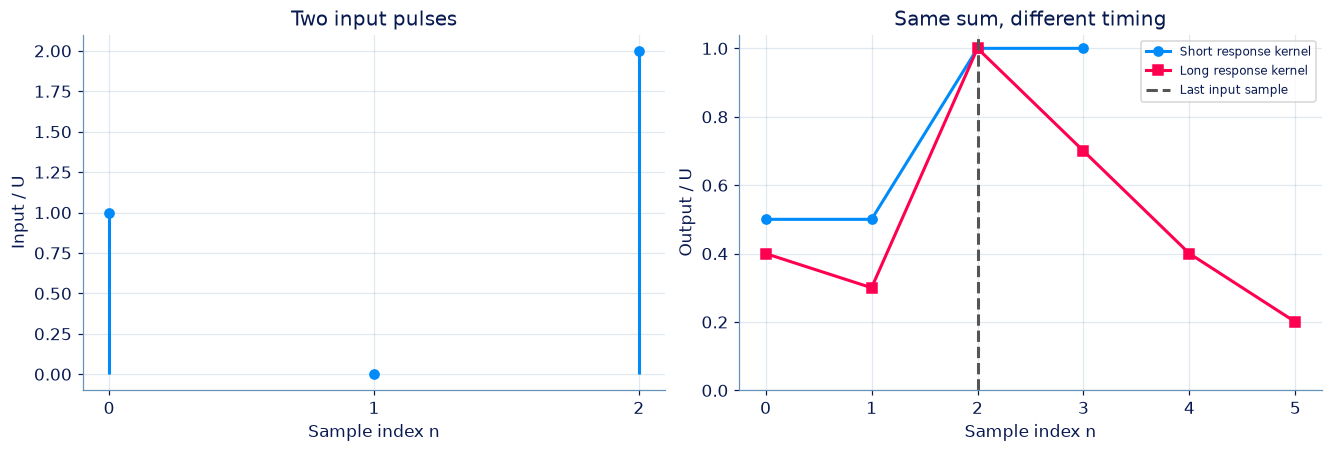

In [4]:
x=[1.,0.,2.]
h_short=[.5,.5];h_long=[.4,.3,.2,.1]
y_short=linear_convolution(x,h_short);y_long=linear_convolution(x,h_long)
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].stem(np.arange(len(x)),x,linefmt=BLUE,markerfmt='o',basefmt=' ')
axes[0].set(xlabel='Sample index n',ylabel='Input / U',title='Two input pulses')
axes[1].plot(np.arange(len(y_short)),y_short,'o-',color=BLUE,label='Short response kernel')
axes[1].plot(np.arange(len(y_long)),y_long,'s-',color=PINK,label='Long response kernel')
axes[1].axvline(len(x)-1,color=GRAY,ls='--',label='Last input sample')
axes[1].set(xlabel='Sample index n',ylabel='Output / U',title='Same sum, different timing');axes[1].legend(fontsize=8)
axes[0].set_xticks(np.arange(len(x)))
axes[1].set_ylim(bottom=0)
plt.show()

## 结果解释

两种核都和为 1，所以完整输出总和都为 3 U 的数值和；较长记忆重新分配了时间，而没有增加输入总和。核的长度在这个传感器模型（model）中决定读数保留多久的输入记忆。非零初始状态时，应再加上内部状态带来的零输入响应（zero-input response）。

### 独立核对

先手算短例，再与成熟库的完整卷积及频域乘法比较。长度不足时故意保留折回结果；下一节会解释此处使用的频域表示。

In [5]:
np.testing.assert_allclose(linear_convolution([1,2,0],[.5,.5]),[.5,1.5,1.,0.])
np.testing.assert_allclose(y_long,np.convolve(x,h_long,mode='full'))
np.testing.assert_allclose(sum(y_long),sum(x)*sum(h_long))
np.testing.assert_allclose(linear_convolution([0,0,1],h_long),[0,0]+h_long)
a=[1.,2.,3.];h=[1.,1.];full=linear_convolution(a,h)
cyclic=np.fft.ifft(np.fft.fft(a,3)*np.fft.fft(h,3)).real
np.testing.assert_allclose(full,[1,3,5,3]);np.testing.assert_allclose(cyclic,[4,3,5])
padded=np.fft.ifft(np.fft.fft(a,4)*np.fft.fft(h,4)).real
np.testing.assert_allclose(padded,full)
print('完整卷积：',full,'；长度 3 的循环卷积：',cyclic.round(12).tolist())

完整卷积： [1.0, 3.0, 5.0, 3.0] ；长度 3 的循环卷积： [4.0, 3.0, 5.0]


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/06-02-卷积、频谱与频率响应/explore/)：改变采样或窗口条件，比较图形后返回本节推导。

## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：把各次输入的响应叠加

一个零初态离散线性时不变（linear time-invariant，LTI）系统的有限脉冲响应（finite impulse response，FIR）已给定。返回输入（input）与核的完整线性卷积（linear convolution）。

**函数与代码模板**

```python
def solve(
    signal: list[float],
    kernel: list[float],
) -> list[float]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `signal` | `list[float]` | 有限输入 x[0]…x[N−1]；区间外为0。 | U |
| `kernel` | `list[float]` | 脉冲响应（impulse response） h[0]…h[M−1]；区间外为0。 | 1 |

**返回值**

直接返回 response（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `response` | `list[float]` | 索引0至N+M−2，包含尾部衰减。 | U |

**计算规则**

y[n]=Σ_j signal[j]*kernel[n−j]，只加有效索引；返回长度 N+M−1，不作循环回绕。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 1≤N,M≤30；每项绝对值≤10。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| signal | 有限输入 x[0]…x[N−1]；区间外为0。 | [1.0, 2.0, 0.0] | U |
| kernel | 脉冲响应（impulse response） h[0]…h[M−1]；区间外为0。 | [0.5, 0.5] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
signal = [1.0, 2.0, 0.0]
kernel = [0.5, 0.5]

result = solve(signal, kernel)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| response | 索引0至N+M−2，包含尾部衰减。 | [0.5, 1.5, 1.0, 0.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.5, 1.5, 1.0, 0.0]
```

**样例解释**

结果 [0.5,1.5,1,0] U；最后一项来自零延拓（zero extension）后的完整尾部，不能把它绕回开头。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：把各次输入的响应叠加](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-linear-convolution)

### 第 2 题 · 多项选择题：卷积表达依靠哪些假设

用一个固定 h[n] 表示零初态系统任意输入（input）的输出（output）。哪些条件支持这一表达？

- **A.** 输入平移后响应相应平移。
- **B.** 饱和器对所有幅值仍满足这一表达。
- **C.** 非零初态响应应另行考虑。
- **D.** 各输入分量的响应可线性叠加。

[作答：卷积表达依靠哪些假设](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-lti-superposition)

### 第 3 题 · 单项选择题：为什么尾部绕回了开头

长度 N、M 的序列直接用长度 L 的 DFT 相乘再逆变换。为了无需额外拆分就得到完整线性卷积（linear convolution），哪项正确？

- **A.** 循环回绕是新的生理反馈（feedback）。
- **B.** 补零改变了系统的脉冲响应（impulse response）。
- **C.** L≥N+M−1 并补零到L，前N+M−1项对应完整线性卷积。
- **D.** 只要L=max(N,M)总是足够。

[作答：为什么尾部绕回了开头](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-circular-wrap)

### 第 4 题 · 多项选择题：单位脉冲与初始状态

离散系统初始静止，输入（input） x[0]=1、其他时刻0。哪些正确？

- **A.** 单位脉冲表示单个离散时刻的输入，不等于随意宽度的连续方波。
- **B.** 输出（output）就是该系统脉冲响应（impulse response）。
- **C.** x[n−j] 的延迟（delay）必须与 h[j] 的索引约定一致。
- **D.** 任意非零初态都不会改变测得的输出。

[作答：单位脉冲与初始状态](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-impulse-meaning)

**进一步阅读**

[MIT 6.003 第 8 讲：Convolution](https://ocw.mit.edu/courses/6-003-signals-and-systems-fall-2011/resources/mit6_003f11_lec08/)：脉冲分解、叠加与卷积。